# MIMM Baseline Analysis

Notebook for the final baseline plots and summary tables across MIMM endpoints.
Current implemented plot: `OS6 hp per inner`.


## 1. OS6 Configuration

Set the `OS6` run and results folder you want to summarize here.


In [38]:
MODEL_DIR_NAME = "ZERO_MLP"  # HEALNET, DYAM, DISTILL-DYAM, SMIL-E, ZERO_MLP, KNN_MLP, VAE_MLP
DATASET_NAME = "MIMM"
RESULTS_DIR_NAME = "results_HP_per_inner"
MISSING_LOCATION = "global"
TRAIN_MISSING_PROP = 0.0
SEED = 22


## 2. OS6 Summary Functions

These helpers load the run files and compute only the final summary tables for `OS6`.


In [39]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score


def resolve_results_root(results_dir_name=None):
    cwd = Path.cwd().resolve()
    project_root = cwd.parent if cwd.name == 'analysis' else cwd
    if results_dir_name is None:
        results_dir_name = globals().get('RESULTS_DIR_NAME', 'results_HP_per_inner')
    return project_root / 'results' / results_dir_name



def get_model_display_name(model_name):
    display_map = {
        'LOGREG_PCA_OS6': 'Logistic',
        'LOGREG_PCA_OS9': 'Logistic',
    }
    return display_map.get(model_name, model_name)


def get_results_root_for_model(model_name, default_results_dir_name, override_results_dir_map=None):
    override_results_dir_map = override_results_dir_map or {}
    return resolve_results_root(override_results_dir_map.get(model_name, default_results_dir_name))


def build_output_dir(base_odir, model_dir_name, dataset_name, missing_location, train_missing_prop, seed):
    mapping = {
        'global': 'GLOBAL',
        'radio': 'RADIO',
        'path': 'PATH',
        'clin': 'CLIN',
        'radio_report': 'RADIO_REPORT',
        'blood': 'BLOOD',
    }
    dataset_label = str(dataset_name).strip().upper()
    key = str(missing_location).strip().lower()
    missing_modality_label = mapping.get(key, key.upper())
    missing_pct = str(float(train_missing_prop) * 100.0)
    return Path(base_odir) / str(model_dir_name).strip() / dataset_label / 'TRAIN_MISSING' / missing_modality_label / missing_pct / f'seed_{seed}'


def load_run_tables(model_dir_name, dataset_name, missing_location='global', train_missing_prop=0.0, seed=4, results_root=None):
    results_root = Path(results_root) if results_root is not None else resolve_results_root()
    run_dir = build_output_dir(
        base_odir=results_root,
        model_dir_name=model_dir_name,
        dataset_name=dataset_name,
        missing_location=missing_location,
        train_missing_prop=train_missing_prop,
        seed=seed,
    )

    outer_metrics_path = run_dir / 'outer_test_metrics.csv'
    test_predictions_path = run_dir / 'test_predictions.csv'

    if not outer_metrics_path.is_file():
        raise FileNotFoundError(f'Could not find outer_test_metrics.csv at: {outer_metrics_path}')
    if not test_predictions_path.is_file():
        raise FileNotFoundError(f'Could not find test_predictions.csv at: {test_predictions_path}')

    outer_df = pd.read_csv(outer_metrics_path)
    test_preds_df = pd.read_csv(test_predictions_path)
    return run_dir, outer_df, test_preds_df


def list_available_seeds(model_dir_name, dataset_name, missing_location='global', train_missing_prop=0.0, results_root=None):
    results_root = Path(results_root) if results_root is not None else resolve_results_root()
    base_dir = build_output_dir(
        base_odir=results_root,
        model_dir_name=model_dir_name,
        dataset_name=dataset_name,
        missing_location=missing_location,
        train_missing_prop=train_missing_prop,
        seed=0,
    ).parent
    if not base_dir.is_dir():
        return []

    seeds = []
    for seed_dir in sorted(base_dir.glob('seed_*')):
        if not seed_dir.is_dir():
            continue
        try:
            seeds.append(int(seed_dir.name.split('seed_', 1)[1]))
        except (IndexError, ValueError):
            continue
    return seeds


def load_test_predictions_across_seeds(model_dir_name, dataset_name, missing_location='global', train_missing_prop=0.0, results_root=None, seeds=None):
    available_seeds = list_available_seeds(
        model_dir_name=model_dir_name,
        dataset_name=dataset_name,
        missing_location=missing_location,
        train_missing_prop=train_missing_prop,
        results_root=results_root,
    )
    if not available_seeds:
        raise FileNotFoundError(
            f'No available seed directories found for model={model_dir_name}, dataset={dataset_name}, '
            f'missing_location={missing_location}, train_missing_prop={train_missing_prop}.'
        )

    target_seeds = available_seeds if seeds is None else [int(seed) for seed in seeds if int(seed) in set(available_seeds)]
    if not target_seeds:
        raise FileNotFoundError(
            f'None of the requested seeds are available for model={model_dir_name}. '
            f'Available seeds: {available_seeds}'
        )

    rows = []
    loaded_run_dirs = []
    for seed in target_seeds:
        run_dir, _, test_preds_df = load_run_tables(
            model_dir_name=model_dir_name,
            dataset_name=dataset_name,
            missing_location=missing_location,
            train_missing_prop=train_missing_prop,
            seed=seed,
            results_root=results_root,
        )
        test_preds_df = test_preds_df.copy()
        test_preds_df['seed'] = int(seed)
        rows.append(test_preds_df)
        loaded_run_dirs.append(run_dir)

    return pd.concat(rows, ignore_index=True), target_seeds, loaded_run_dirs


def compute_group_metrics(test_preds_df, score_col='ensemble_prob', label_col='y_true', threshold=0.5):
    if score_col not in test_preds_df.columns:
        raise KeyError(f"Column '{score_col}' not found in test_predictions.csv")

    summary_group_cols = ['test_missing_prop']
    if 'test_missing_location' in test_preds_df.columns and test_preds_df['test_missing_location'].nunique(dropna=False) > 1:
        summary_group_cols = ['test_missing_location', 'test_missing_prop']

    group_cols = summary_group_cols.copy()
    if 'outer_fold' in test_preds_df.columns:
        group_cols.append('outer_fold')

    rows = []
    for keys, g in test_preds_df.groupby(group_cols, dropna=False):
        y_true = g[label_col].to_numpy(dtype=np.int64)
        y_score = g[score_col].to_numpy(dtype=np.float64)
        y_pred = (y_score >= threshold).astype(np.int64)

        if len(np.unique(y_true)) > 1:
            auc = float(roc_auc_score(y_true, y_score))
            aucpr = float(average_precision_score(y_true, y_score))
        else:
            auc = 0.5
            aucpr = float(y_true.mean())

        acc = float((y_pred == y_true).mean())

        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: val for col, val in zip(group_cols, keys)}
        row['auc'] = auc
        row['aucpr'] = aucpr
        row['acc'] = acc
        rows.append(row)

    metrics_by_group_df = pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)
    return metrics_by_group_df, summary_group_cols


def build_final_summary_table(outer_df, test_preds_df):
    metrics_by_group_df, summary_group_cols = compute_group_metrics(test_preds_df)

    summary_df = (
        metrics_by_group_df
        .groupby(summary_group_cols, dropna=False)
        .agg(
            mean_auc=('auc', 'mean'),
            std_auc=('auc', 'std'),
            mean_aucpr=('aucpr', 'mean'),
            std_aucpr=('aucpr', 'std'),
            mean_acc=('acc', 'mean'),
            std_acc=('acc', 'std'),
        )
        .reset_index()
        .sort_values(summary_group_cols)
        .reset_index(drop=True)
    )

    if {'eval_missing_prop', 'selected_inner_mean_AUC'}.issubset(outer_df.columns):
        outer_group_cols = ['eval_missing_prop']
        rename_map = {'eval_missing_prop': 'test_missing_prop'}

        if 'test_missing_location' in summary_group_cols and 'eval_missing_location' in outer_df.columns:
            outer_group_cols = ['eval_missing_location', 'eval_missing_prop']
            rename_map = {
                'eval_missing_location': 'test_missing_location',
                'eval_missing_prop': 'test_missing_prop',
            }

        selected_inner_df = (
            outer_df
            .groupby(outer_group_cols, dropna=False)
            .agg(
                selected_inner_mean_auc_mean=('selected_inner_mean_AUC', 'mean'),
                selected_inner_mean_auc_std=('selected_inner_mean_AUC', 'std'),
            )
            .reset_index()
            .rename(columns=rename_map)
            .sort_values(summary_group_cols)
            .reset_index(drop=True)
        )

        summary_df = summary_df.merge(
            selected_inner_df,
            on=summary_group_cols,
            how='left',
        )

    return summary_df


def summarize_single_model(model_dir_name, dataset_name, missing_location='global', train_missing_prop=0.0, seed=4, results_root=None):
    run_dir, outer_df, test_preds_df = load_run_tables(
        model_dir_name=model_dir_name,
        dataset_name=dataset_name,
        missing_location=missing_location,
        train_missing_prop=train_missing_prop,
        seed=seed,
        results_root=results_root,
    )
    summary_df = build_final_summary_table(outer_df=outer_df, test_preds_df=test_preds_df)
    return {
        'run_dir': run_dir,
        'outer_df': outer_df,
        'test_preds_df': test_preds_df,
        'summary_df': summary_df,
    }


def summarize_multiple_models(model_names_to_compare, dataset_name, missing_location='global', train_missing_prop=0.0, seed=4, results_root=None):
    all_models_summary = {}

    for model_name in model_names_to_compare:
        print(f'=== {model_name} ===')
        try:
            outputs = summarize_single_model(
                model_dir_name=model_name,
                dataset_name=dataset_name,
                missing_location=missing_location,
                train_missing_prop=train_missing_prop,
                seed=seed,
                results_root=results_root,
            )
        except FileNotFoundError as exc:
            print(f'Skipping: {exc}')
            continue

        summary_df = outputs['summary_df'].copy()
        all_models_summary[model_name] = summary_df
        display(summary_df)

    return all_models_summary


def build_inner_model_auc_by_test_split_table(test_preds_df, label_col='y_true', focus_test_missing_prop=0.0):
    prob_cols = sorted(
        col for col in test_preds_df.columns
        if col.startswith('inner_model_') and col.endswith('_prob')
    )
    if not prob_cols:
        raise KeyError("No 'inner_model_*_prob' columns found in test_predictions.csv")

    required_cols = {'outer_fold', 'test_missing_prop', label_col}
    missing_required = [col for col in required_cols if col not in test_preds_df.columns]
    if missing_required:
        raise KeyError(f'Missing required columns in test_predictions.csv: {missing_required}')

    df = test_preds_df.copy()
    df = df[df['test_missing_prop'].astype(float) == float(focus_test_missing_prop)].copy()
    if df.empty:
        raise ValueError(f'No rows found for test_missing_prop={focus_test_missing_prop}')

    group_cols = []
    if 'seed' in df.columns:
        group_cols.append('seed')
    group_cols.append('outer_fold')
    if 'test_missing_location' in df.columns:
        group_cols.append('test_missing_location')
    group_cols.append('test_missing_prop')

    rows = []
    for prob_col in prob_cols:
        inner_model_idx = int(prob_col.split('_')[2])
        for keys, g in df.groupby(group_cols, dropna=False):
            y_true = g[label_col].to_numpy(dtype=np.int64)
            y_score = g[prob_col].to_numpy(dtype=np.float64)
            if len(np.unique(y_true)) > 1:
                auc = float(roc_auc_score(y_true, y_score))
            else:
                auc = 0.5

            if not isinstance(keys, tuple):
                keys = (keys,)
            row = {col: val for col, val in zip(group_cols, keys)}
            row['inner_model_idx'] = inner_model_idx
            row['auc'] = auc
            rows.append(row)

    out = pd.DataFrame(rows)
    sort_cols = [col for col in ['test_missing_location', 'test_missing_prop', 'outer_fold', 'inner_model_idx'] if col in out.columns]
    out = out.sort_values(sort_cols).reset_index(drop=True)
    return out


def summarize_inner_model_auc_by_test_split_for_models(
    model_names_to_compare,
    dataset_name,
    missing_location='global',
    train_missing_prop=0.0,
    seed=4,
    focus_test_missing_prop=0.0,
    results_root=None,
):
    all_models_inner_auc_tables = {}

    for model_name in model_names_to_compare:
        print(f'=== {model_name} ===')
        try:
            _, _, test_preds_df = load_run_tables(
                model_dir_name=model_name,
                dataset_name=dataset_name,
                missing_location=missing_location,
                train_missing_prop=train_missing_prop,
                seed=seed,
                results_root=results_root,
            )
        except FileNotFoundError as exc:
            print(f'Skipping: {exc}')
            continue

        auc_df = build_inner_model_auc_by_test_split_table(
            test_preds_df=test_preds_df,
            focus_test_missing_prop=focus_test_missing_prop,
        )
        all_models_inner_auc_tables[model_name] = auc_df
        display(auc_df)

    return all_models_inner_auc_tables





## 3. OS6 Final Summary Table For One Model

Run this cell to display the final summary table for the selected `OS6` model.


In [40]:
single_model_outputs = summarize_single_model(
    model_dir_name=MODEL_DIR_NAME,
    dataset_name=DATASET_NAME,
    missing_location=MISSING_LOCATION,
    train_missing_prop=TRAIN_MISSING_PROP,
    seed=SEED,
)

run_dir = single_model_outputs['run_dir']
outer_df = single_model_outputs['outer_df']
test_preds_df = single_model_outputs['test_preds_df']
final_summary_df = single_model_outputs['summary_df']

print(f'Run directory: {run_dir}')
print('\n=== OS6 final summary table ===')
display(final_summary_df)


Run directory: /Users/marcalbesa/Desktop/TFM/git_exp/methods/results/results_HP_per_inner/ZERO_MLP/MIMM/TRAIN_MISSING/GLOBAL/0.0/seed_22

=== OS6 final summary table ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.567870,0.048504,0.703381,0.042373,0.572870,0.034508,0.726217,0.024375
1,0.2,0.577664,0.045559,0.724834,0.045601,0.569549,0.045812,0.726217,0.024375
2,0.4,0.585164,0.052660,0.732036,0.033802,0.558835,0.064937,0.726217,0.024375
3,0.6,0.573173,0.068606,0.708113,0.047667,0.537469,0.073750,0.726217,0.024375
4,0.8,0.551208,0.055291,0.687376,0.047825,0.501504,0.114867,0.726217,0.024375


## 4. OS6 Final Summary Tables Across Models (Optional)

Edit the list and run this cell if you want to compare several `OS6` models.


In [41]:
MODEL_NAMES_TO_COMPARE = [
    'ZERO_MLP',
    'KNN_MLP',
    'VAE_MLP',
    'DYAM',
    'DISTILL-DYAM',
    'LOGREG_PCA_OS6',
]

all_models_summary = summarize_multiple_models(
    model_names_to_compare=MODEL_NAMES_TO_COMPARE,
    dataset_name=DATASET_NAME,
    missing_location=MISSING_LOCATION,
    train_missing_prop=TRAIN_MISSING_PROP,
    seed=SEED,
)


=== ZERO_MLP ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.567870,0.048504,0.703381,0.042373,0.572870,0.034508,0.726217,0.024375
1,0.2,0.577664,0.045559,0.724834,0.045601,0.569549,0.045812,0.726217,0.024375
2,0.4,0.585164,0.052660,0.732036,0.033802,0.558835,0.064937,0.726217,0.024375
3,0.6,0.573173,0.068606,0.708113,0.047667,0.537469,0.073750,0.726217,0.024375
4,0.8,0.551208,0.055291,0.687376,0.047825,0.501504,0.114867,0.726217,0.024375


=== KNN_MLP ===
Skipping: Could not find outer_test_metrics.csv at: /Users/marcalbesa/Desktop/TFM/git_exp/methods/results/results_HP_per_inner/KNN_MLP/MIMM/TRAIN_MISSING/GLOBAL/0.0/seed_22/outer_test_metrics.csv
=== VAE_MLP ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.609082,0.077875,0.751057,0.047483,0.594361,0.047188,0.721947,0.017905
1,0.2,0.613721,0.066180,0.734316,0.037388,0.601441,0.015063,0.721947,0.017905
2,0.4,0.592164,0.038862,0.713801,0.032776,0.580263,0.045665,0.721947,0.017905
3,0.6,0.564747,0.035210,0.700887,0.033866,0.601504,0.017845,0.721947,0.017905
4,0.8,0.517655,0.048805,0.677371,0.056936,0.569549,0.071611,0.721947,0.017905


=== DYAM ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.577965,0.107726,0.712101,0.065899,0.580201,0.075327,0.714573,0.016703
1,0.2,0.565775,0.105428,0.707841,0.070480,0.555326,0.078473,0.714573,0.016703
2,0.4,0.588940,0.090871,0.726338,0.068232,0.551692,0.060077,0.714573,0.016703
3,0.6,0.590214,0.058805,0.728880,0.061222,0.537469,0.069292,0.714573,0.016703
4,0.8,0.565039,0.058847,0.696156,0.060418,0.547807,0.082773,0.714573,0.016703


=== DISTILL-DYAM ===


,test_missing_prop,mean_auc,std_auc,mean_aucpr,std_aucpr,mean_acc,std_acc,selected_inner_mean_auc_mean,selected_inner_mean_auc_std
0,0.0,0.580964,0.045851,0.709950,0.046974,0.551880,0.055017,0.762257,0.022006
1,0.2,0.571251,0.055643,0.709230,0.051136,0.555201,0.024048,0.762257,0.022006
2,0.4,0.553673,0.050108,0.699901,0.031397,0.565789,0.033022,0.762257,0.022006
3,0.6,0.554598,0.046783,0.689968,0.042687,0.562531,0.071946,0.762257,0.022006
4,0.8,0.505439,0.075111,0.656855,0.038011,0.519298,0.089890,0.762257,0.022006


=== LOGREG_PCA_OS6 ===
Skipping: Could not find outer_test_metrics.csv at: /Users/marcalbesa/Desktop/TFM/git_exp/methods/results/results_HP_per_inner/LOGREG_PCA_OS6/MIMM/TRAIN_MISSING/GLOBAL/0.0/seed_22/outer_test_metrics.csv


## 5. OS6 Final Plot: HP Per Inner

Implemented plot for the `OS6` baseline using the `hp per inner` results.
It fixes `train_missing_prop=0.0`, `missing_location="global"`, and `test_missing_prop=0.0`.
Each individual point is the outer-test AUC of one retained inner model for one outer fold across all available seeds.


OS6 baseline setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0
ZERO_MLP (ZERO_MLP) seeds: [18473, 2002, 22, 4, 55602]
KNN_MLP (KNN_MLP) seeds: [18473, 2002, 4, 55602]
VAE_MLP (VAE_MLP) seeds: [18473, 2002, 22, 4, 55602]
DYAM (DYAM) seeds: [18473, 2002, 22, 4, 55602]
DISTILL-DYAM (DISTILL-DYAM) seeds: [18473, 2002, 22, 4]
Logistic (LOGREG_PCA_OS6) seeds: [42]
Total points: 580

=== OS6 baseline inner-model AUC table ===


,seed,outer_fold,test_missing_location,test_missing_prop,inner_model_idx,auc,model_name,model_display_name
0,4,1,global,0.0,1,0.456349,DISTILL-DYAM,DISTILL-DYAM
1,4,1,global,0.0,2,0.326720,DISTILL-DYAM,DISTILL-DYAM
2,4,1,global,0.0,3,0.562169,DISTILL-DYAM,DISTILL-DYAM
3,4,1,global,0.0,4,0.496032,DISTILL-DYAM,DISTILL-DYAM
4,4,1,global,0.0,5,0.485450,DISTILL-DYAM,DISTILL-DYAM
...,...,...,...,...,...,...,...,...
575,55602,5,global,0.0,1,0.755556,ZERO_MLP,ZERO_MLP
576,55602,5,global,0.0,2,0.640278,ZERO_MLP,ZERO_MLP
577,55602,5,global,0.0,3,0.545833,ZERO_MLP,ZERO_MLP
578,55602,5,global,0.0,4,0.479167,ZERO_MLP,ZERO_MLP


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/baseline_boxplot_os6_HP_inner.png


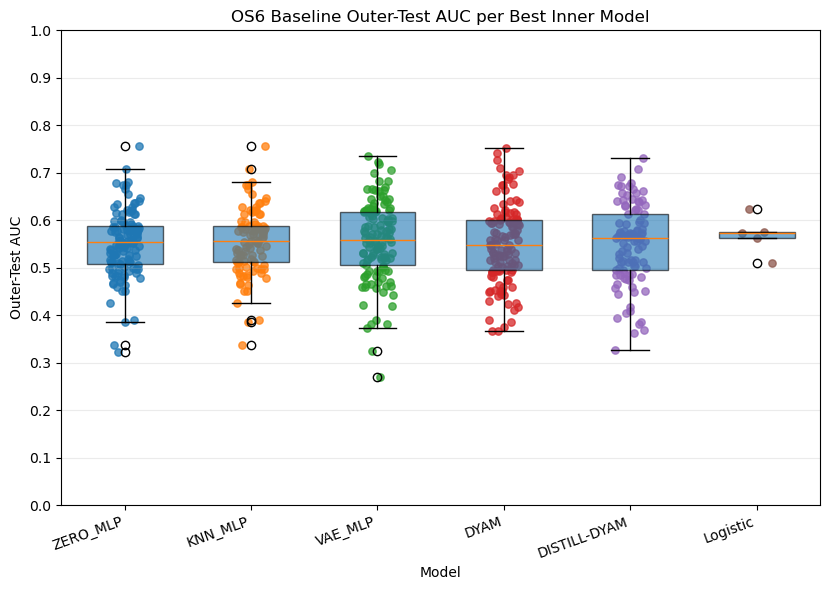

In [42]:
import matplotlib.pyplot as plt

BASELINE_MISSING_LOCATION = 'global'
BASELINE_TRAIN_MISSING_PROP = 0.0
BASELINE_TEST_MISSING_PROP = 0.0

baseline_rows = []
baseline_seed_map = {}
for model_name in MODEL_NAMES_TO_COMPARE:
    try:
        test_preds_df, available_seeds, _ = load_test_predictions_across_seeds(
            model_dir_name=model_name,
            dataset_name=DATASET_NAME,
            missing_location=BASELINE_MISSING_LOCATION,
            train_missing_prop=BASELINE_TRAIN_MISSING_PROP,
        )
    except FileNotFoundError as exc:
        print(f'Skipping {model_name}: {exc}')
        continue

    baseline_seed_map[model_name] = available_seeds
    auc_df = build_inner_model_auc_by_test_split_table(
        test_preds_df=test_preds_df,
        focus_test_missing_prop=BASELINE_TEST_MISSING_PROP,
    )
    auc_df = auc_df.copy()
    auc_df['model_name'] = model_name
    auc_df['model_display_name'] = get_model_display_name(model_name)
    baseline_rows.append(auc_df)

if not baseline_rows:
    raise ValueError('No baseline inner-model AUC tables were found for the selected models.')

baseline_inner_auc_df = pd.concat(baseline_rows, ignore_index=True)
baseline_inner_auc_df = baseline_inner_auc_df.sort_values(
    ['model_name', 'seed', 'outer_fold', 'inner_model_idx']
).reset_index(drop=True)

print('OS6 baseline setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0')
for model_name in MODEL_NAMES_TO_COMPARE:
    if model_name in baseline_seed_map:
        display_name = get_model_display_name(model_name)
        print(f'{display_name} ({model_name}) seeds: {baseline_seed_map[model_name]}')
print(f'Total points: {len(baseline_inner_auc_df)}')
print()
print('=== OS6 baseline inner-model AUC table ===')
display(baseline_inner_auc_df)

plot_df = baseline_inner_auc_df[['model_name', 'model_display_name', 'auc']].copy()
model_order = [model_name for model_name in MODEL_NAMES_TO_COMPARE if model_name in plot_df['model_name'].unique()]
display_order = [get_model_display_name(model_name) for model_name in model_order]
boxplot_data = [
    plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    for model_name in model_order
]

fig, ax = plt.subplots(figsize=(max(8, len(model_order) * 1.4), 6))
bp = ax.boxplot(boxplot_data, tick_labels=display_order, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_alpha(0.6)

for x_pos, model_name in enumerate(model_order, start=1):
    y = plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    if len(y) == 0:
        continue
    jitter = np.linspace(-0.12, 0.12, num=len(y)) if len(y) > 1 else np.array([0.0])
    ax.scatter(np.full(len(y), x_pos) + jitter, y, alpha=0.75, s=28)

ax.set_title('OS6 Baseline Outer-Test AUC per Best Inner Model')
ax.set_xlabel('Model')
ax.set_ylabel('Outer-Test AUC')
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

figures_dir = Path.cwd() / 'figures' if Path.cwd().name == 'analysis' else Path.cwd() / 'analysis' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / 'baseline_boxplot_os6_HP_inner.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {figure_path}')
plt.show()


## 6. OS6 Final Plot: HP Per Outer

Implemented plot for the `OS6` baseline using the `hp per outer` results.
It fixes `train_missing_prop=0.0`, `missing_location="global"`, and `test_missing_prop=0.0`.
Each individual point is the outer-test AUC of one retained inner model for one outer fold across all available seeds, loaded from `results_HP_per_outer`.


Skipping DISTILL-DYAM: No available seed directories found for model=DISTILL-DYAM, dataset=MIMM, missing_location=global, train_missing_prop=0.0.
OS6 hp-per-outer setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0
ZERO_MLP (ZERO_MLP) seeds: [2002, 22, 4]
KNN_MLP (KNN_MLP) seeds: [22]
VAE_MLP (VAE_MLP) seeds: [22]
DYAM (DYAM) seeds: [2002, 22]
Logistic (LOGREG_PCA_OS6) seeds: [42]
Total points: 180

=== OS6 hp-per-outer inner-model AUC table ===


,seed,outer_fold,test_missing_location,test_missing_prop,inner_model_idx,auc,model_name,model_display_name
0,22,1,global,0.0,1,0.466931,DYAM,DYAM
1,22,1,global,0.0,2,0.539683,DYAM,DYAM
2,22,1,global,0.0,3,0.458995,DYAM,DYAM
3,22,1,global,0.0,4,0.485450,DYAM,DYAM
4,22,1,global,0.0,5,0.473545,DYAM,DYAM
...,...,...,...,...,...,...,...,...
175,2002,5,global,0.0,1,0.556944,ZERO_MLP,ZERO_MLP
176,2002,5,global,0.0,2,0.476389,ZERO_MLP,ZERO_MLP
177,2002,5,global,0.0,3,0.493056,ZERO_MLP,ZERO_MLP
178,2002,5,global,0.0,4,0.563889,ZERO_MLP,ZERO_MLP


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/baseline_boxplot_os6_HP_outer.png


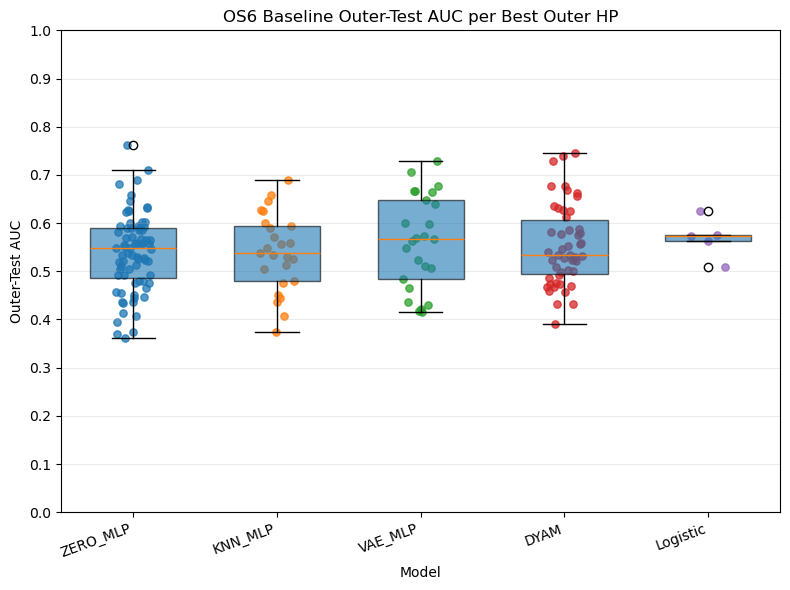

In [43]:
import matplotlib.pyplot as plt

OS6_HP_OUTER_RESULTS_DIR_NAME = 'results_HP_per_outer'
OS6_HP_OUTER_MISSING_LOCATION = 'global'
OS6_HP_OUTER_TRAIN_MISSING_PROP = 0.0
OS6_HP_OUTER_TEST_MISSING_PROP = 0.0

hp_outer_rows = []
hp_outer_seed_map = {}
for model_name in MODEL_NAMES_TO_COMPARE:
    try:
        test_preds_df, available_seeds, _ = load_test_predictions_across_seeds(
            model_dir_name=model_name,
            dataset_name=DATASET_NAME,
            missing_location=OS6_HP_OUTER_MISSING_LOCATION,
            train_missing_prop=OS6_HP_OUTER_TRAIN_MISSING_PROP,
            results_root=resolve_results_root(OS6_HP_OUTER_RESULTS_DIR_NAME),
        )
    except FileNotFoundError as exc:
        print(f'Skipping {model_name}: {exc}')
        continue

    hp_outer_seed_map[model_name] = available_seeds
    auc_df = build_inner_model_auc_by_test_split_table(
        test_preds_df=test_preds_df,
        focus_test_missing_prop=OS6_HP_OUTER_TEST_MISSING_PROP,
    )
    auc_df = auc_df.copy()
    auc_df['model_name'] = model_name
    auc_df['model_display_name'] = get_model_display_name(model_name)
    hp_outer_rows.append(auc_df)

if not hp_outer_rows:
    raise ValueError('No OS6 hp-per-outer inner-model AUC tables were found for the selected models.')

os6_hp_outer_auc_df = pd.concat(hp_outer_rows, ignore_index=True)
os6_hp_outer_auc_df = os6_hp_outer_auc_df.sort_values(
    ['model_name', 'seed', 'outer_fold', 'inner_model_idx']
).reset_index(drop=True)

print('OS6 hp-per-outer setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0')
for model_name in MODEL_NAMES_TO_COMPARE:
    if model_name in hp_outer_seed_map:
        display_name = get_model_display_name(model_name)
        print(f'{display_name} ({model_name}) seeds: {hp_outer_seed_map[model_name]}')
print(f'Total points: {len(os6_hp_outer_auc_df)}')
print()
print('=== OS6 hp-per-outer inner-model AUC table ===')
display(os6_hp_outer_auc_df)

plot_df = os6_hp_outer_auc_df[['model_name', 'model_display_name', 'auc']].copy()
model_order = [model_name for model_name in MODEL_NAMES_TO_COMPARE if model_name in plot_df['model_name'].unique()]
display_order = [get_model_display_name(model_name) for model_name in model_order]
boxplot_data = [
    plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    for model_name in model_order
]

fig, ax = plt.subplots(figsize=(max(8, len(model_order) * 1.4), 6))
bp = ax.boxplot(boxplot_data, tick_labels=display_order, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_alpha(0.6)

for x_pos, model_name in enumerate(model_order, start=1):
    y = plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    if len(y) == 0:
        continue
    jitter = np.linspace(-0.12, 0.12, num=len(y)) if len(y) > 1 else np.array([0.0])
    ax.scatter(np.full(len(y), x_pos) + jitter, y, alpha=0.75, s=28)

ax.set_title('OS6 Baseline Outer-Test AUC per Best Outer HP')
ax.set_xlabel('Model')
ax.set_ylabel('Outer-Test AUC')
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

figures_dir = Path.cwd() / 'figures' if Path.cwd().name == 'analysis' else Path.cwd() / 'analysis' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / 'baseline_boxplot_os6_HP_outer.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {figure_path}')
plt.show()


## 7. OS9 Final Plot: HP Per Outer

Implemented plot for the `OS9` baseline using the available `hp per outer` results.
It fixes `train_missing_prop=0.0`, `missing_location="global"`, and `test_missing_prop=0.0`.
Each individual point is the outer-test AUC of one retained inner model for one outer fold across all available seeds.

Deep models are loaded from `results_mean_OS_9`.
The logistic baseline is loaded from `results_HP_per_outer` as `LOGREG_PCA_OS9` and displayed as `Logistic`.


Skipping KNN_MLP: No available seed directories found for model=KNN_MLP, dataset=MIMM, missing_location=global, train_missing_prop=0.0.
Skipping VAE_MLP: No available seed directories found for model=VAE_MLP, dataset=MIMM, missing_location=global, train_missing_prop=0.0.
Skipping DYAM: No available seed directories found for model=DYAM, dataset=MIMM, missing_location=global, train_missing_prop=0.0.
Skipping DISTILL-DYAM: No available seed directories found for model=DISTILL-DYAM, dataset=MIMM, missing_location=global, train_missing_prop=0.0.
OS9 hp-per-outer setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0
ZERO_MLP (ZERO_MLP) seeds: [18473, 2002, 22, 4, 55602] | source: results_mean_OS_9
Logistic (LOGREG_PCA_OS9) seeds: [42] | source: results_HP_per_outer
Total points: 130

=== OS9 hp-per-outer inner-model AUC table ===


,seed,outer_fold,test_missing_location,test_missing_prop,inner_model_idx,auc,model_name,model_display_name,results_dir_name
0,42,1,global,0.0,1,0.616049,LOGREG_PCA_OS9,Logistic,results_HP_per_outer
1,42,2,global,0.0,1,0.591315,LOGREG_PCA_OS9,Logistic,results_HP_per_outer
2,42,3,global,0.0,1,0.573436,LOGREG_PCA_OS9,Logistic,results_HP_per_outer
3,42,4,global,0.0,1,0.643678,LOGREG_PCA_OS9,Logistic,results_HP_per_outer
4,42,5,global,0.0,1,0.547436,LOGREG_PCA_OS9,Logistic,results_HP_per_outer
...,...,...,...,...,...,...,...,...,...
125,55602,5,global,0.0,1,0.624359,ZERO_MLP,ZERO_MLP,results_mean_OS_9
126,55602,5,global,0.0,2,0.594872,ZERO_MLP,ZERO_MLP,results_mean_OS_9
127,55602,5,global,0.0,3,0.532051,ZERO_MLP,ZERO_MLP,results_mean_OS_9
128,55602,5,global,0.0,4,0.489744,ZERO_MLP,ZERO_MLP,results_mean_OS_9


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/baseline_boxplot_os9_HP_outer.png


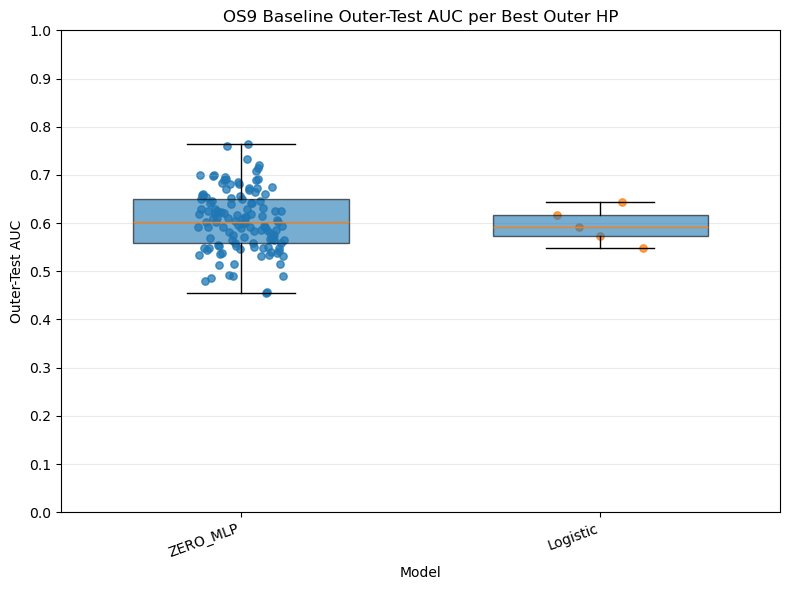

In [44]:
import matplotlib.pyplot as plt

OS9_MODEL_NAMES_TO_COMPARE = [
    'ZERO_MLP',
    'KNN_MLP',
    'VAE_MLP',
    'DYAM',
    'DISTILL-DYAM',
    'LOGREG_PCA_OS9',
]

OS9_HP_OUTER_DEFAULT_RESULTS_DIR_NAME = 'results_mean_OS_9'
OS9_HP_OUTER_RESULTS_DIR_OVERRIDES = {
    'LOGREG_PCA_OS9': 'results_HP_per_outer',
}
OS9_HP_OUTER_MISSING_LOCATION = 'global'
OS9_HP_OUTER_TRAIN_MISSING_PROP = 0.0
OS9_HP_OUTER_TEST_MISSING_PROP = 0.0

os9_hp_outer_rows = []
os9_hp_outer_seed_map = {}
os9_hp_outer_results_dir_map = {}
for model_name in OS9_MODEL_NAMES_TO_COMPARE:
    results_root = get_results_root_for_model(
        model_name=model_name,
        default_results_dir_name=OS9_HP_OUTER_DEFAULT_RESULTS_DIR_NAME,
        override_results_dir_map=OS9_HP_OUTER_RESULTS_DIR_OVERRIDES,
    )
    try:
        test_preds_df, available_seeds, _ = load_test_predictions_across_seeds(
            model_dir_name=model_name,
            dataset_name=DATASET_NAME,
            missing_location=OS9_HP_OUTER_MISSING_LOCATION,
            train_missing_prop=OS9_HP_OUTER_TRAIN_MISSING_PROP,
            results_root=results_root,
        )
    except FileNotFoundError as exc:
        print(f'Skipping {model_name}: {exc}')
        continue

    os9_hp_outer_seed_map[model_name] = available_seeds
    os9_hp_outer_results_dir_map[model_name] = results_root.name
    auc_df = build_inner_model_auc_by_test_split_table(
        test_preds_df=test_preds_df,
        focus_test_missing_prop=OS9_HP_OUTER_TEST_MISSING_PROP,
    )
    auc_df = auc_df.copy()
    auc_df['model_name'] = model_name
    auc_df['model_display_name'] = get_model_display_name(model_name)
    auc_df['results_dir_name'] = results_root.name
    os9_hp_outer_rows.append(auc_df)

if not os9_hp_outer_rows:
    raise ValueError('No OS9 hp-per-outer inner-model AUC tables were found for the selected models.')

os9_hp_outer_auc_df = pd.concat(os9_hp_outer_rows, ignore_index=True)
os9_hp_outer_auc_df = os9_hp_outer_auc_df.sort_values(
    ['model_name', 'seed', 'outer_fold', 'inner_model_idx']
).reset_index(drop=True)

print('OS9 hp-per-outer setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0')
for model_name in OS9_MODEL_NAMES_TO_COMPARE:
    if model_name in os9_hp_outer_seed_map:
        display_name = get_model_display_name(model_name)
        results_dir_name = os9_hp_outer_results_dir_map.get(model_name, OS9_HP_OUTER_DEFAULT_RESULTS_DIR_NAME)
        print(f'{display_name} ({model_name}) seeds: {os9_hp_outer_seed_map[model_name]} | source: {results_dir_name}')
print(f'Total points: {len(os9_hp_outer_auc_df)}')
print()
print('=== OS9 hp-per-outer inner-model AUC table ===')
display(os9_hp_outer_auc_df)

plot_df = os9_hp_outer_auc_df[['model_name', 'model_display_name', 'auc']].copy()
model_order = [model_name for model_name in OS9_MODEL_NAMES_TO_COMPARE if model_name in plot_df['model_name'].unique()]
display_order = [get_model_display_name(model_name) for model_name in model_order]
boxplot_data = [
    plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    for model_name in model_order
]

fig, ax = plt.subplots(figsize=(max(8, len(model_order) * 1.4), 6))
bp = ax.boxplot(boxplot_data, tick_labels=display_order, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_alpha(0.6)

for x_pos, model_name in enumerate(model_order, start=1):
    y = plot_df.loc[plot_df['model_name'] == model_name, 'auc'].to_numpy(dtype=float)
    if len(y) == 0:
        continue
    jitter = np.linspace(-0.12, 0.12, num=len(y)) if len(y) > 1 else np.array([0.0])
    ax.scatter(np.full(len(y), x_pos) + jitter, y, alpha=0.75, s=28)

ax.set_title('OS9 Baseline Outer-Test AUC per Best Outer HP')
ax.set_xlabel('Model')
ax.set_ylabel('Outer-Test AUC')
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()

figures_dir = Path.cwd() / 'figures' if Path.cwd().name == 'analysis' else Path.cwd() / 'analysis' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / 'baseline_boxplot_os9_HP_outer.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {figure_path}')
plt.show()


## 8. ZERO_MLP Across Endpoints: Best Outer HP

Comparison of `ZERO_MLP` outer-test AUC across the available endpoints using the corresponding `best outer hp` results.
It fixes `train_missing_prop=0.0`, `missing_location="global"`, and `test_missing_prop=0.0`.
Each individual point is the outer-test AUC of one retained inner model for one outer fold across all available seeds.


ZERO_MLP endpoint comparison setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0
OS6 seeds: [2002, 22, 4] | source: results_HP_per_outer
OS9 seeds: [18473, 2002, 22, 4, 55602] | source: results_mean_OS_9
Total points: 200

=== ZERO_MLP endpoint AUC table ===


,seed,outer_fold,test_missing_location,test_missing_prop,inner_model_idx,auc,endpoint,results_dir_name
0,4,1,global,0.0,1,0.548942,OS6,results_HP_per_outer
1,4,1,global,0.0,2,0.457672,OS6,results_HP_per_outer
2,4,1,global,0.0,3,0.369048,OS6,results_HP_per_outer
3,4,1,global,0.0,4,0.395503,OS6,results_HP_per_outer
4,4,1,global,0.0,5,0.492063,OS6,results_HP_per_outer
...,...,...,...,...,...,...,...,...
195,55602,5,global,0.0,1,0.624359,OS9,results_mean_OS_9
196,55602,5,global,0.0,2,0.594872,OS9,results_mean_OS_9
197,55602,5,global,0.0,3,0.532051,OS9,results_mean_OS_9
198,55602,5,global,0.0,4,0.489744,OS9,results_mean_OS_9


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/baseline_boxplot_zero_mlp_endpoints_HP_outer.png


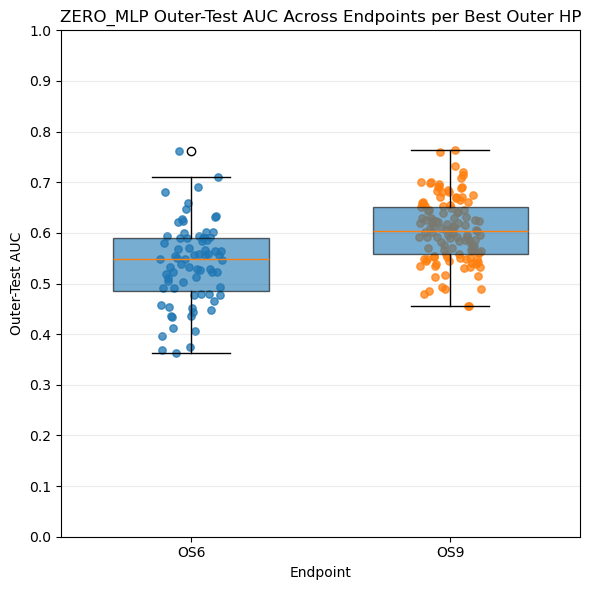

In [45]:
import matplotlib.pyplot as plt

ZERO_MLP_ENDPOINT_RESULTS = {
    'OS6': 'results_HP_per_outer',
    'OS9': 'results_mean_OS_9',
}
ZERO_MLP_ENDPOINT_MODEL_NAME = 'ZERO_MLP'
ZERO_MLP_ENDPOINT_MISSING_LOCATION = 'global'
ZERO_MLP_ENDPOINT_TRAIN_MISSING_PROP = 0.0
ZERO_MLP_ENDPOINT_TEST_MISSING_PROP = 0.0

zero_mlp_endpoint_rows = []
zero_mlp_endpoint_seed_map = {}
for endpoint_name, results_dir_name in ZERO_MLP_ENDPOINT_RESULTS.items():
    results_root = resolve_results_root(results_dir_name)
    try:
        test_preds_df, available_seeds, _ = load_test_predictions_across_seeds(
            model_dir_name=ZERO_MLP_ENDPOINT_MODEL_NAME,
            dataset_name=DATASET_NAME,
            missing_location=ZERO_MLP_ENDPOINT_MISSING_LOCATION,
            train_missing_prop=ZERO_MLP_ENDPOINT_TRAIN_MISSING_PROP,
            results_root=results_root,
        )
    except FileNotFoundError as exc:
        print(f'Skipping {endpoint_name}: {exc}')
        continue

    zero_mlp_endpoint_seed_map[endpoint_name] = available_seeds
    auc_df = build_inner_model_auc_by_test_split_table(
        test_preds_df=test_preds_df,
        focus_test_missing_prop=ZERO_MLP_ENDPOINT_TEST_MISSING_PROP,
    )
    auc_df = auc_df.copy()
    auc_df['endpoint'] = endpoint_name
    auc_df['results_dir_name'] = results_dir_name
    zero_mlp_endpoint_rows.append(auc_df)

if not zero_mlp_endpoint_rows:
    raise ValueError('No ZERO_MLP endpoint AUC tables were found for the selected endpoint results.')

zero_mlp_endpoint_auc_df = pd.concat(zero_mlp_endpoint_rows, ignore_index=True)
zero_mlp_endpoint_auc_df = zero_mlp_endpoint_auc_df.sort_values(
    ['endpoint', 'seed', 'outer_fold', 'inner_model_idx']
).reset_index(drop=True)

print('ZERO_MLP endpoint comparison setting: missing_location=global, train_missing_prop=0.0, test_missing_prop=0.0')
for endpoint_name, results_dir_name in ZERO_MLP_ENDPOINT_RESULTS.items():
    if endpoint_name in zero_mlp_endpoint_seed_map:
        print(f'{endpoint_name} seeds: {zero_mlp_endpoint_seed_map[endpoint_name]} | source: {results_dir_name}')
print(f'Total points: {len(zero_mlp_endpoint_auc_df)}')
print()
print('=== ZERO_MLP endpoint AUC table ===')
display(zero_mlp_endpoint_auc_df)

plot_df = zero_mlp_endpoint_auc_df[['endpoint', 'auc']].copy()
endpoint_order = [endpoint_name for endpoint_name in ZERO_MLP_ENDPOINT_RESULTS if endpoint_name in plot_df['endpoint'].unique()]
boxplot_data = [
    plot_df.loc[plot_df['endpoint'] == endpoint_name, 'auc'].to_numpy(dtype=float)
    for endpoint_name in endpoint_order
]

fig, ax = plt.subplots(figsize=(max(6, len(endpoint_order) * 1.8), 6))
bp = ax.boxplot(boxplot_data, tick_labels=endpoint_order, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_alpha(0.6)

for x_pos, endpoint_name in enumerate(endpoint_order, start=1):
    y = plot_df.loc[plot_df['endpoint'] == endpoint_name, 'auc'].to_numpy(dtype=float)
    if len(y) == 0:
        continue
    jitter = np.linspace(-0.12, 0.12, num=len(y)) if len(y) > 1 else np.array([0.0])
    ax.scatter(np.full(len(y), x_pos) + jitter, y, alpha=0.75, s=28)

ax.set_title('ZERO_MLP Outer-Test AUC Across Endpoints per Best Outer HP')
ax.set_xlabel('Endpoint')
ax.set_ylabel('Outer-Test AUC')
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

figures_dir = Path.cwd() / 'figures' if Path.cwd().name == 'analysis' else Path.cwd() / 'analysis' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / 'baseline_boxplot_zero_mlp_endpoints_HP_outer.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {figure_path}')
plt.show()
